## Changes made to improve accuracy

The original run scored **59.7% accuracy with 0% recall/precision on the "Fake" class**
— the model had simply collapsed to always predicting "Real". The fixes below target
the root causes:

1. **Critical bug fix (Dataset class):** images were loaded using the row's *positional*
   index (`f"{idx}.jpg"`) instead of the Fakeddit submission id (`row["id"]`). Almost no
   files matched, so nearly every sample silently fell back to an all-zero image tensor —
   the image branch was contributing no real signal at all. Fixed to use `row["id"]`.
2. **Class-weighted loss** so the model can't get a low loss just by predicting the
   majority class on this imbalanced (~60/40) dataset.
3. **A real validation split** + best-checkpoint saving + early stopping, so training
   is actually monitored instead of trusting whatever the last epoch happens to produce.
4. **Differential learning rates** — a much higher LR for the randomly-initialized
   classifier head than for the pretrained encoders, plus a linear warmup/decay
   schedule and gradient clipping.
5. **Partial layer freezing** of DistilBERT/ResNet50's earlier layers to reduce
   overfitting given the small fine-tuning set.
6. **Light image augmentation** on the training split only (flip/crop/color jitter),
   with a separate clean deterministic transform for val/test.
7. **More training data** (configurable `NUM_SAMPLES`, raised from 5,000) and the
   training loop is now actually enabled (it was commented out before).


In [ ]:
import os
import torch
import pandas as pd
import torch.nn as nn
import requests

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split

In [ ]:
# print('Reinstalling torch and torchvision to resolve sympy compatibility issues. Please restart the runtime after this cell finishes.')
# !pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
# !unzip "fakeddit_images.zip"
# !unzip "xmap_model.zip"

In [ ]:
df = pd.read_csv("test_public.csv")

print(df.shape)
print(df.head())

(59319, 16)
                author                                        clean_title  \
0         trustbytrust                                          stargazer   
1                  NaN                                               yeah   
2             chaseoes  pd phoenix car thief gets instructions from yo...   
3            SFepicure  as trump accuses iran he has one problem his o...   
4  fragments_from_Work                                believers hezbollah   

    created_utc       domain  hasImage       id  \
0  1.425139e+09          NaN      True  cozywbv   
1  1.438173e+09          NaN      True  ctk61yw   
2  1.560492e+09    abc15.com      True   c0gl7r   
3  1.560606e+09  nytimes.com      True   c0xdqy   
4  1.515139e+09  i.imgur.com      True   7o9rmx   

                                           image_url linked_submission_id  \
0                     http://i.imgur.com/BruWKDi.jpg               2xct9d   
1                     http://i.imgur.com/JRZT727.jpg            

### Download images from `image_url`

Only needed if `fakeddit_images/` doesn't already contain a matching `{id}.jpg` for
every row you plan to train on. Downloads are keyed by `id` (matching the Dataset
class fix above), skip files that already exist, retry on transient failures, and
run concurrently for speed. Rows with `hasImage == False` or a missing `image_url`
are skipped.

In [ ]:
import os
import requests
from io import BytesIO
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

# ==========================
# Configuration
# ==========================

IMAGE_DIR = "fakeddit_images"
os.makedirs(IMAGE_DIR, exist_ok=True)

NUM_SAMPLES = 15000          # Number of samples to use
DOWNLOAD_ROWS = NUM_SAMPLES  # Download images only for these samples

MAX_WORKERS = 32
TIMEOUT = 10
MAX_RETRIES = 2

HEADERS = {
    "User-Agent": "Mozilla/5.0 (X-MAP dataset builder)"
}

# ==========================
# Select rows
# ==========================

download_df = df.iloc[:DOWNLOAD_ROWS]

candidates = download_df[
    (download_df["hasImage"] == True) &
    (download_df["image_url"].notna())
]

print(f"Total rows selected      : {len(download_df)}")
print(f"Rows having image URL    : {len(candidates)}")

# ==========================
# Download function
# ==========================

def download_one(row):

    image_id = row["id"]
    url = row["image_url"]

    dest_path = os.path.join(
        IMAGE_DIR,
        f"{image_id}.jpg"
    )

    # Skip already downloaded images
    if os.path.exists(dest_path):
        return image_id, "skipped"

    for attempt in range(MAX_RETRIES + 1):

        try:
            response = requests.get(
                url,
                headers=HEADERS,
                timeout=TIMEOUT
            )

            response.raise_for_status()

            image = Image.open(
                BytesIO(response.content)
            ).convert("RGB")

            image.save(dest_path, "JPEG")

            return image_id, "downloaded"

        except Exception as e:

            if attempt == MAX_RETRIES:
                return image_id, f"failed: {e}"

# ==========================
# Parallel Download
# ==========================

results = {
    "downloaded": 0,
    "skipped": 0,
    "failed": 0
}

failures = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:

    futures = [
        executor.submit(download_one, row)
        for _, row in candidates.iterrows()
    ]

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Downloading Images"
    ):

        image_id, status = future.result()

        if status == "downloaded":
            results["downloaded"] += 1

        elif status == "skipped":
            results["skipped"] += 1

        else:
            results["failed"] += 1
            failures.append((image_id, status))

# ==========================
# Summary
# ==========================

print("\nDownload Summary")
print("-" * 40)
print("Downloaded :", results["downloaded"])
print("Skipped    :", results["skipped"])
print("Failed     :", results["failed"])

print("\nTotal images available:",
      len(os.listdir(IMAGE_DIR)))

if failures:
    print("\nFirst 10 failures:")
    for image_id, status in failures[:10]:
        print(image_id, "-", status)

Total rows selected      : 15000
Rows having image URL    : 14958


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Download Summary
----------------------------------------
Downloaded : 14170
Skipped    : 0
Failed     : 788

Total images available: 14170

First 10 failures:
8g3xtm - failed: 404 Client Error: Not Found for url: https://external-preview.redd.it/4-bDBCtwD9WQGl1OhcoSjs5q0Kc2yzWSONQholD_QJI.jpg?width=320&crop=smart&auto=webp&s=655d4896ad51b5728262952477f19d58f4a3f3fd
b5t5j9 - failed: 404 Client Error: Not Found for url: https://preview.redd.it/75p8v8fq8io21.jpg?width=320&crop=smart&auto=webp&s=9ef18518497671969cb209d74db8fac6a857dd05
axrt6n - failed: 404 Client Error: Not Found for url: https://preview.redd.it/vt4zlvaixdk21.jpg?width=320&crop=smart&auto=webp&s=d28c7ad12c42528b4bbe387de8c1af444701e5e3
8akm5j - failed: 404 Client Error: Not Found for url: https://preview.redd.it/oid83x3zkjq01.jpg?width=320&crop=smart&auto=webp&s=a3b0507b6d8e69537c20160fdf48b38bc364e7d3
98i0f3 - failed: 404 Client Error: Not Found for url: https://preview.redd.it/4q1aztpzhzg11.jpg?width=320&crop=smart&aut

In [ ]:
# Two separate pipelines:
# - train_transform: light augmentation so the image encoder sees more
#   varied views of each picture and doesn't just memorize the small
#   training set (previously identical to eval, i.e. zero regularization
#   for the vision branch).
# - eval_transform: deterministic, no augmentation, used for val/test so
#   metrics are stable and reproducible.
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Kept as an alias for backward compatibility with the LIME/GradCAM
# explainability cells later in the notebook, which expect a single
# deterministic transform.
transform = eval_transform

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# NOTE: the previous version trained on only the first 5,000 rows and
# had no validation set, so the only way to see how training went was
# the final test-set numbers. Both are fixed here.
#
# Increase/decrease NUM_SAMPLES depending on how much time/compute you
# have (this CSV has ~59k rows) -- more labeled data gives the model
# more signal to learn the Fake vs Real boundary.
NUM_SAMPLES = 15000

subset_df = df.iloc[:NUM_SAMPLES].reset_index(drop=True)

# Split off a held-out test set first, then split the remainder into
# train/val. The val set lets us monitor generalization *during*
# training (checkpointing the best epoch, early stopping) instead of
# only discovering a collapsed model after the fact.
train_df, temp_df = train_test_split(
    subset_df,
    test_size=0.3,
    random_state=42,
    stratify=subset_df["2_way_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=(2 / 3),   # -> 10% val / 20% test of the full subset
    random_state=42,
    stratify=temp_df["2_way_label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print(train_df["2_way_label"].value_counts(normalize=True))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 10500
2_way_label
0    0.602857
1    0.397143
Name: proportion, dtype: float64
Val  : 1500
Test : 3000


In [ ]:
class FakedditDataset(Dataset):

    def __init__(self, dataframe, tokenizer, image_transform=None, max_length=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        # Text
        text = str(row["clean_title"])

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Image
        # BUG FIX: image files are named after the Fakeddit submission id
        # (row["id"], e.g. "cozywbv.jpg") -- NOT the positional row index.
        # The original code built the path from `idx`, so for nearly every
        # sample it pointed at a file that doesn't exist and silently fell
        # back to an all-zero image tensor. That means the image branch
        # was feeding the model an (almost) identical, uninformative
        # signal for the entire dataset -- a major reason the model
        # collapsed to predicting a single class.
        image_id = row["id"]
        image_path = os.path.join("fakeddit_images", f"{image_id}.jpg")

        try:
            if os.path.exists(image_path):
                image = Image.open(image_path).convert("RGB")

                if self.image_transform:
                    image = self.image_transform(image)

            else:
                image = torch.zeros((3, 224, 224))

        except Exception:
            image = torch.zeros((3, 224, 224))

        # Label
        label = torch.tensor(
            int(row["2_way_label"]),
            dtype=torch.long
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "image": image,
            "label": label
        }

In [ ]:
train_dataset = FakedditDataset(
    dataframe=train_df,
    tokenizer=tokenizer,
    image_transform=train_transform
)

val_dataset = FakedditDataset(
    dataframe=val_df,
    tokenizer=tokenizer,
    image_transform=eval_transform
)

test_dataset = FakedditDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    image_transform=eval_transform
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

10500
1500
3000


In [ ]:
class XMAP(nn.Module):

    def __init__(self, freeze_text_layers=4, freeze_image_blocks=("layer1", "layer2")):
        super(XMAP, self).__init__()

        # Text Encoder
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )

        # Freeze the embeddings + first N transformer layers of DistilBERT.
        # With only a few thousand fine-tuning examples, updating every
        # parameter overfits fast and can wreck the pretrained language
        # representations (catastrophic forgetting). Freezing the lower
        # layers keeps general language features intact and lets only the
        # top layers (more task-specific) adapt.
        for param in self.text_encoder.embeddings.parameters():
            param.requires_grad = False

        for layer in self.text_encoder.transformer.layer[:freeze_text_layers]:
            for param in layer.parameters():
                param.requires_grad = False

        # Image Encoder
        self.image_encoder = resnet50(
            weights=ResNet50_Weights.DEFAULT
        )

        # Freeze the early conv blocks (generic edge/texture features) and
        # only fine-tune the later blocks, which encode more task-specific
        # visual features -- same overfitting rationale as above.
        for name, child in self.image_encoder.named_children():
            if name in freeze_image_blocks:
                for param in child.parameters():
                    param.requires_grad = False

        # Remove the final classification layer
        self.image_encoder.fc = nn.Identity()

        # Multimodal Classifier
        # Added BatchNorm after each hidden layer for more stable training
        # now that the encoders and head are trained with different LRs,
        # and slightly higher dropout on the first layer since 768+2048
        # concatenated features is a wide, overfit-prone input for a few
        # thousand training examples.
        self.classifier = nn.Sequential(
            nn.Linear(768 + 2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, images):

        # Text Features
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_features = text_output.last_hidden_state[:, 0, :]

        # Image Features
        image_features = self.image_encoder(images)

        # Feature Fusion
        fusion = torch.cat(
            (text_features, image_features),
            dim=1
        )

        # Classification
        logits = self.classifier(fusion)

        return logits, fusion

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = XMAP().to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


In [ ]:
# The dataset is imbalanced (~60/40 in this subset). An unweighted loss
# lets the model reach a low average loss just by always predicting the
# majority class -- exactly the failure mode from before (0% recall on
# the Fake class). Weighting by inverse class frequency makes mistakes
# on the minority class cost more, pushing the model to actually learn
# to distinguish it.
class_counts = train_df["2_way_label"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (len(class_counts) * c) for c in class_counts],
    dtype=torch.float
).to(device)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights: tensor([0.8294, 1.2590], device='cuda:0')


In [ ]:
from transformers import get_linear_schedule_with_warmup

NUM_EPOCHS = 3

# Differential learning rates: the pretrained encoders only need small
# nudges, while the freshly-initialized classifier head needs to learn
# from scratch and benefits from a much higher learning rate. A single
# tiny LR (2e-5) for everything -- as before -- barely moves the
# randomly-initialized classifier weights in a handful of epochs, which
# is a big part of why the model never learned to use the Fake class.
optimizer = AdamW([
    {"params": [p for p in model.text_encoder.parameters() if p.requires_grad], "lr": 2e-5},
    {"params": [p for p in model.image_encoder.parameters() if p.requires_grad], "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-3},
], weight_decay=0.01)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [ ]:
# ============================
# Training Loop
# ============================
from sklearn.metrics import accuracy_score, f1_score

best_val_f1 = 0.0
patience = 2
patience_counter = 0

for epoch in range(NUM_EPOCHS):

    # ---- Train ----
    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs, fusion = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            images=images
        )

        loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping stabilizes training when fine-tuning large
        # pretrained encoders jointly with a randomly-initialized head.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ---- Validate ----
    model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs, _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                images=images
            )

            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # ---- Checkpoint best model + early stopping ----
    # Track F1 (not accuracy) as the checkpoint criterion since accuracy
    # alone can still look fine for a model that ignores the minority
    # class on an imbalanced set.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "xmap_model_best.pth")
        print("  -> New best model saved (xmap_model_best.pth)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  -> No improvement for {patience} epochs, stopping early.")
            break

Epoch 1/3
Train Loss: 0.4474 | Val Acc: 0.8160 | Val F1: 0.7937
  -> New best model saved (xmap_model_best.pth)
Epoch 2/3
Train Loss: 0.3294 | Val Acc: 0.8520 | Val F1: 0.8218
  -> New best model saved (xmap_model_best.pth)
Epoch 3/3
Train Loss: 0.2753 | Val Acc: 0.8580 | Val F1: 0.8244
  -> New best model saved (xmap_model_best.pth)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Evaluate the BEST checkpoint (highest validation F1), not necessarily
# whatever state the model is in after the final epoch (early stopping
# may have kept training a couple more epochs past the best one).
if os.path.exists("xmap_model_best.pth"):
    model.load_state_dict(torch.load("xmap_model_best.pth", map_location=device))
    print("Loaded best checkpoint (by validation F1) for test evaluation.")

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs, fusion = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            images=images
        )

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report")
print(classification_report(all_labels, all_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(all_labels, all_predictions))

Loaded best checkpoint (by validation F1) for test evaluation.
Accuracy : 0.8640
Precision: 0.8047
Recall   : 0.8682
F1 Score : 0.8352

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      1809
           1       0.80      0.87      0.84      1191

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.87      0.86      0.86      3000


Confusion Matrix
[[1558  251]
 [ 157 1034]]


In [ ]:
# The best checkpoint (by validation F1) was already saved during
# training as "xmap_model_best.pth". Mirror it to "xmap_model.pth" so
# the loading cell below (and anything downstream expecting that
# filename) picks up the improved model.
import shutil

if os.path.exists("xmap_model_best.pth"):
    shutil.copy("xmap_model_best.pth", "xmap_model.pth")
    print("Best model copied to xmap_model.pth")
else:
    torch.save(model.state_dict(), "xmap_model.pth")
    print("Model saved successfully as xmap_model.pth")

Best model copied to xmap_model.pth


In [ ]:
model = XMAP().to(device)

model.load_state_dict(torch.load("xmap_model.pth", map_location=device))

model.eval()

print("Model loaded successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [ ]:
!pip install lime grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from lime.lime_text import LimeTextExplainer
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [ ]:
# Initialize LIME Text Explainer
lime_explainer = LimeTextExplainer(
    class_names=["Real", "Fake"]
)

In [ ]:
def predict_proba(texts):

    model.eval()

    probabilities = []

    with torch.no_grad():

        for text in texts:

            encoding = tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=128,
                return_tensors="pt"
            )

            input_ids = encoding["input_ids"].to(device)
            attention_mask = encoding["attention_mask"].to(device)

            image = torch.zeros((1,3,224,224)).to(device)

            outputs, _ = model(
                input_ids,
                attention_mask,
                image
            )

            probs = F.softmax(outputs, dim=1)
            probabilities.append(probs.cpu().numpy()[0])

    return np.array(probabilities)

In [ ]:
target_layers = [model.image_encoder.layer4[-1]]

class ImageModelWrapper(nn.Module):

    def __init__(self, model, input_ids, attention_mask):
        super().__init__()

        self.model = model
        self.input_ids = input_ids
        self.attention_mask = attention_mask

    def forward(self, image):

        outputs, _ = self.model(
            self.input_ids,
            self.attention_mask,
            image
        )

        return outputs

In [ ]:
def explain_sample(sample_index):

    model.eval()

    sample = test_dataset[sample_index]

    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    image_tensor = sample["image"].unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        outputs, _ = model(
            input_ids,
            attention_mask,
            image_tensor
        )

        probabilities = F.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

    label_map = {
        0: "Real",
        1: "Fake"
    }

    print("="*70)
    print("Original Text:\n")
    print(test_df.iloc[sample_index]["clean_title"])
    print()

    print("Actual Label    :", label_map[sample["label"].item()])
    print("Predicted Label :", label_map[prediction.item()])
    print(f"Confidence      : {confidence.item():.4f}")
    print("="*70)

    # ---------------- LIME ----------------

    explanation = lime_explainer.explain_instance(
        test_df.iloc[sample_index]["clean_title"],
        predict_proba,
        num_features=10
    )

    explanation.show_in_notebook(text=True)

    # ---------------- GradCAM ----------------

    wrapped_model = ImageModelWrapper(
        model,
        input_ids,
        attention_mask
    )

    cam = GradCAM(
        model=wrapped_model,
        target_layers=target_layers
    )

    grayscale_cam = cam(
        input_tensor=image_tensor,
        targets=[ClassifierOutputTarget(prediction.item())]
    )

    image_np = sample["image"].permute(1,2,0).cpu().numpy()

    image_np = (image_np-image_np.min()) / (
        image_np.max()-image_np.min()+1e-8
    )

    visualization = show_cam_on_image(
        image_np,
        grayscale_cam[0],
        use_rgb=True
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(image_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

In [ ]:
class TextAgent:
    """
    Handles text processing and feature extraction.
    """

    def __init__(self, tokenizer, model):
        self.tokenizer = tokenizer
        self.model = model

    def extract_features(self, text):

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        with torch.no_grad():
            text_features = self.model.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            ).last_hidden_state[:, 0, :]

        return text_features, input_ids, attention_mask

In [ ]:
class ImageAgent:
    """
    Handles image processing and feature extraction.
    """

    def __init__(self, model):
        self.model = model

    def extract_features(self, image):

        # Add batch dimension if required
        if image.dim() == 3:
            image = image.unsqueeze(0)

        image = image.to(device)

        with torch.no_grad():
            image_features = self.model.image_encoder(image)

        return image_features

In [ ]:
class FusionAgent:
    """
    Combines text and image features.
    """

    def fuse(self, text_features, image_features):

        # Concatenate text and image features
        fused_features = torch.cat(
            (text_features, image_features),
            dim=1
        )

        return fused_features

In [ ]:
class DecisionAgent:
    """
    Makes the final Fake/Real prediction.
    """

    def __init__(self, model):
        self.model = model

    def predict(self, fused_features):

        with torch.no_grad():

            logits = self.model.classifier(fused_features)

            probabilities = F.softmax(logits, dim=1)

            predicted_class = torch.argmax(
                probabilities,
                dim=1
            )

        return logits, probabilities, predicted_class

In [ ]:
class ExplanationAgent:
    """
    Generates explanations for model predictions.
    """

    def explain(self, sample_index):

        explain_sample(sample_index)

Prediction: Fake
Confidence: 0.8009459376335144
Original Text:

apples at my work are disney branded

Actual Label    : Fake
Predicted Label : Fake
Confidence      : 0.8009


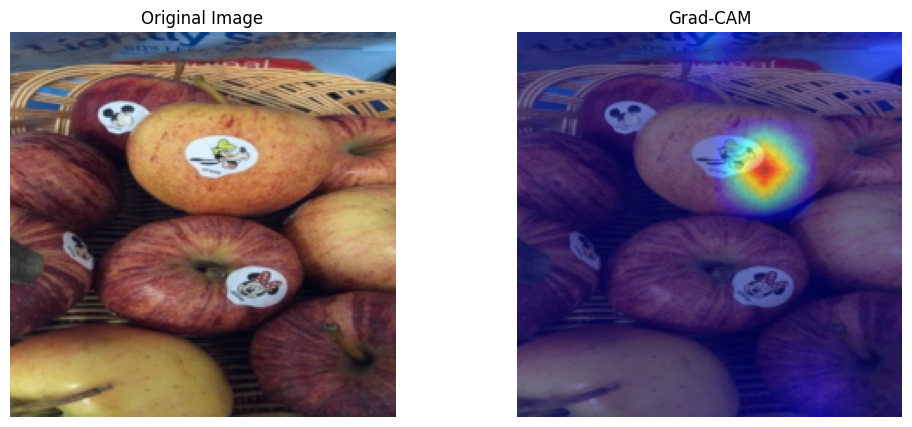

In [ ]:
# Initialize all agents
text_agent = TextAgent(tokenizer, model)
image_agent = ImageAgent(model)
fusion_agent = FusionAgent()
decision_agent = DecisionAgent(model)
explanation_agent = ExplanationAgent()

# Example sample
sample_index = 10

sample = test_dataset[sample_index]
text = test_df.iloc[sample_index]["clean_title"]
image = sample["image"]

# Step 1: Text features
text_features, input_ids, attention_mask = text_agent.extract_features(text)

# Step 2: Image features
image_features = image_agent.extract_features(image)

# Step 3: Fusion
fused_features = fusion_agent.fuse(text_features, image_features)

# Step 4: Prediction
_, probabilities, prediction = decision_agent.predict(fused_features)

labels = ["Real", "Fake"]

print("Prediction:", labels[prediction.item()])
print("Confidence:", probabilities.max().item())

# Step 5: Explain
explanation_agent.explain(sample_index)